In [4]:
"""
Horizon-wise MAE Analysis
Dynamic Wind Graph-ST
"""

import os
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import sys

PROJECT_ROOT = "/Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)"

sys.path.append(PROJECT_ROOT)

from torch.utils.data import DataLoader
from src.data.dataset import MultisiteDataset
from src.models.graph_st_transformer import GraphSTTransformer
from src.utils.metrics import masked_mae

In [5]:
PROJECT_ROOT = "/Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)"

NPZ_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "splits_final_Yscaled_Tin24_Tout6_stride1.npz",
)

CKPT_PATH = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "checkpoints",
    "graph_st_best.pt",
)

COORDS_PATH = os.path.join(
    PROJECT_ROOT,
    "configs",
    "site_coords_raw.npy",
)

SCALER_PATH = os.path.join(
    PROJECT_ROOT,
    "configs",
    "target_scaler.json",
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [6]:
#Load Everything
# Load scaler
with open(SCALER_PATH, "r") as f:
    scaler = json.load(f)

mean = torch.tensor(scaler["mean"], dtype=torch.float32, device=device)
std = torch.tensor(scaler["std"], dtype=torch.float32, device=device)

# Load dataset
test_ds = MultisiteDataset(NPZ_PATH, split="test")
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# Load coords
site_coords = torch.tensor(np.load(COORDS_PATH), dtype=torch.float32, device=device)

# Load adjacency
A = torch.tensor(
    np.load(os.path.join(PROJECT_ROOT, "data", "processed", "adjacency_final.npy")),
    dtype=torch.float32,
    device=device
)

# Create model
model = GraphSTTransformer(
    num_features=test_ds.X.shape[-1],
    tin=test_ds.tin,
    tout=test_ds.tout,
    num_sites=test_ds.X.shape[2],
).to(device)

ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

TEST loaded:
X: torch.Size([4539, 24, 7, 28])
Y: torch.Size([4539, 6, 7, 2])


GraphSTTransformer(
  (in_proj): Linear(in_features=28, out_features=128, bias=True)
  (temporal_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (graph_layer): GraphConv(
    (linear): Linear(in_features=128, out_features=128, bias=True)
  )
  (spatial_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncod

In [7]:
#Compute Horizon-wise MAE
def inverse_scale(y):
    return y * std.view(1,1,1,-1) + mean.view(1,1,1,-1)

horizon_mae = np.zeros(6)

with torch.no_grad():
    for X, Y, _, Y_mask in test_loader:
        X = X.to(device)
        Y = Y.to(device)
        Y_mask = Y_mask.to(device)

        Y_hat = model(X, A, site_coords)

        Y_hat_real = inverse_scale(Y_hat)
        Y_real = inverse_scale(Y)

        for h in range(6):
            mae_h = masked_mae(
                Y_hat_real[:, h:h+1],
                Y_real[:, h:h+1],
                Y_mask[:, h:h+1]
            ).item()
            horizon_mae[h] += mae_h

horizon_mae /= len(test_loader)

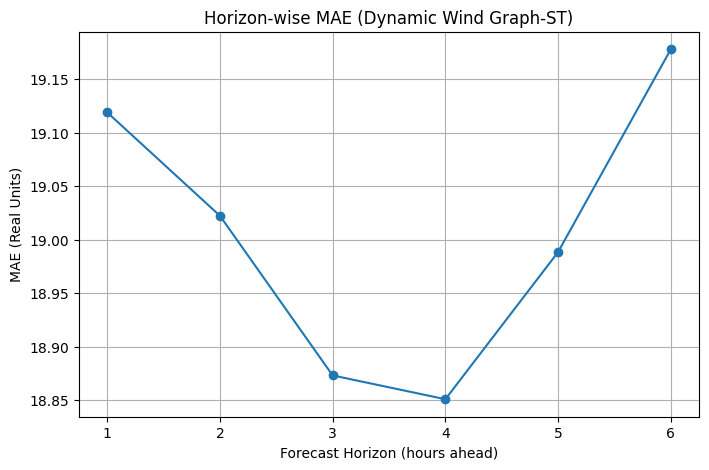

In [8]:
#Plot It
plt.figure(figsize=(8,5))
plt.plot(range(1,7), horizon_mae, marker="o")
plt.title("Horizon-wise MAE (Dynamic Wind Graph-ST)")
plt.xlabel("Forecast Horizon (hours ahead)")
plt.ylabel("MAE (Real Units)")
plt.grid(True)
plt.show()

In [9]:
# Per-site MAE

num_sites = 7
site_mae = np.zeros(num_sites)

with torch.no_grad():
    for X, Y, _, Y_mask in test_loader:
        X = X.to(device)
        Y = Y.to(device)
        Y_mask = Y_mask.to(device)

        Y_hat = model(X, A, site_coords)

        Y_hat_real = inverse_scale(Y_hat)
        Y_real = inverse_scale(Y)

        for s in range(num_sites):
            mae_s = masked_mae(
                Y_hat_real[:, :, s:s+1],
                Y_real[:, :, s:s+1],
                Y_mask[:, :, s:s+1]
            ).item()
            site_mae[s] += mae_s

site_mae /= len(test_loader)

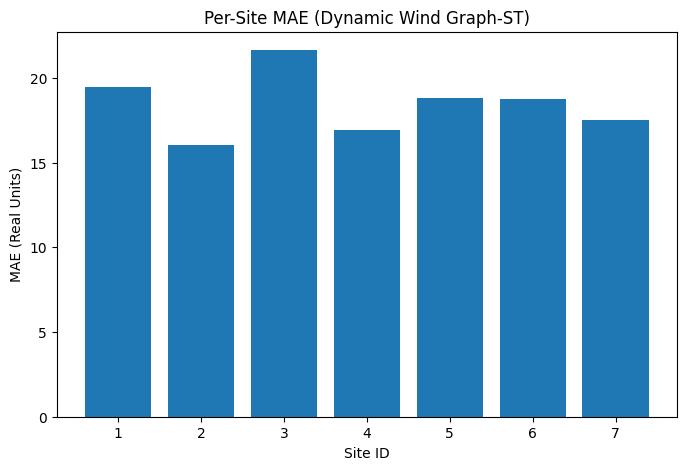

In [10]:
plt.figure(figsize=(8,5))
plt.bar(range(1,8), site_mae)
plt.title("Per-Site MAE (Dynamic Wind Graph-ST)")
plt.xlabel("Site ID")
plt.ylabel("MAE (Real Units)")
plt.xticks(range(1,8))
plt.show()

In [11]:
# Residual distribution (all sites, all horizons)

residuals = []

with torch.no_grad():
    for X, Y, _, Y_mask in test_loader:
        X = X.to(device)
        Y = Y.to(device)
        Y_mask = Y_mask.to(device)

        Y_hat = model(X, A, site_coords)

        Y_hat_real = inverse_scale(Y_hat)
        Y_real = inverse_scale(Y)

        mask = Y_mask.bool()
        diff = (Y_hat_real - Y_real)[mask]
        residuals.extend(diff.cpu().numpy())

residuals = np.array(residuals)

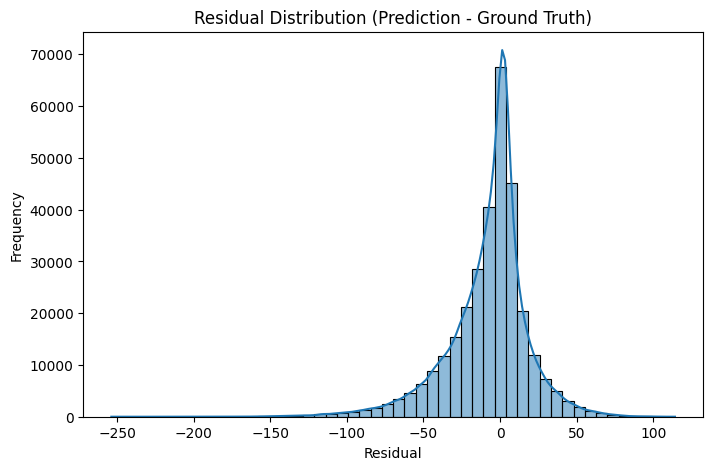

Mean residual: -7.6105638


In [12]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution (Prediction - Ground Truth)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

print("Mean residual:", residuals.mean())

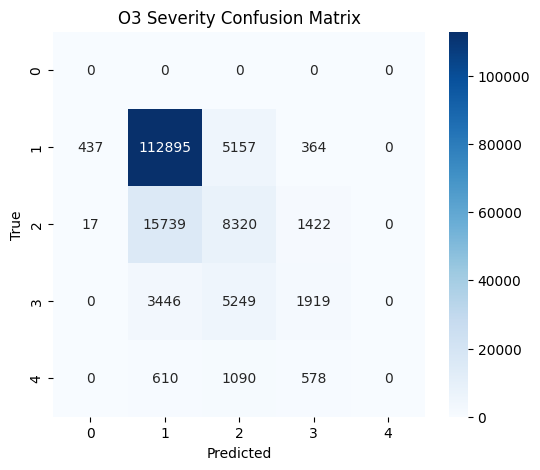

In [13]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def categorize(values):
    bins = [0, 50, 100, 150, 1000]
    return np.digitize(values, bins)

true_classes = []
pred_classes = []

with torch.no_grad():
    for X, Y, _, Y_mask in test_loader:
        X = X.to(device)
        Y = Y.to(device)
        Y_mask = Y_mask.to(device)

        Y_hat = model(X, A, site_coords)

        Y_hat_real = inverse_scale(Y_hat)
        Y_real = inverse_scale(Y)

        mask = Y_mask.bool()

        # use O3 only (index 0)
        true_vals = Y_real[..., 0][mask[..., 0]].cpu().numpy()
        pred_vals = Y_hat_real[..., 0][mask[..., 0]].cpu().numpy()

        true_classes.extend(categorize(true_vals))
        pred_classes.extend(categorize(pred_vals))

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("O3 Severity Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [14]:
from sklearn.decomposition import PCA

# Extract embeddings for one batch
model.eval()

with torch.no_grad():
    X, _, _, _ = next(iter(test_loader))
    X = X.to(device)
    emb = model.in_proj(X)
    
    # temporal encoder
    B, Tin, S, D = emb.shape
    emb = emb.permute(0,2,1,3)
    emb = emb.reshape(B*S, Tin, -1)
    emb = model.temporal_encoder(emb)
    emb = emb[:, -1, :]
    emb = emb.reshape(B, S, -1)
    
    # spatial encoder output
    emb = model.spatial_encoder(emb)
    
    # average across batch
    emb_mean = emb.mean(dim=0).cpu().numpy()  # (S, D)

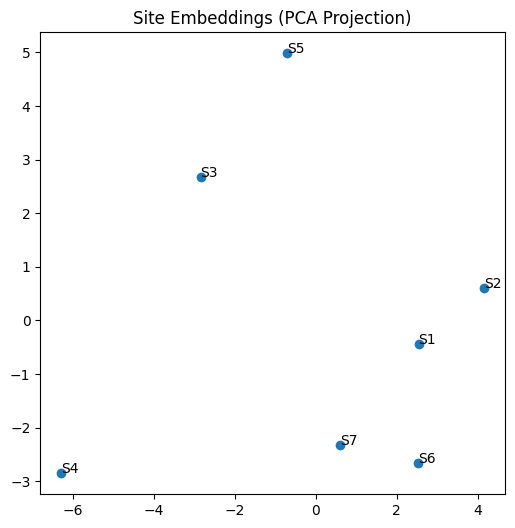

In [15]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_mean)

plt.figure(figsize=(6,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1])

for i in range(7):
    plt.text(emb_2d[i,0], emb_2d[i,1], f"S{i+1}")

plt.title("Site Embeddings (PCA Projection)")
plt.show()